# Stage 5: WOE & Binning
## Meridian Trust Bank — Personal Loan Application Credit Scorecard

**Business question:** how do we convert raw variables — some numeric, some
categorical, some with special missing-value meaning — into a common,
model-ready form that's also directly interpretable to an underwriter?

**The answer the industry converged on: Weight of Evidence (WOE).**

## Why WOE, in plain terms

For any bin of a variable (e.g. "bureau score 650-700"), WOE compares the
proportion of Goods in that bin to the proportion of Bads in that bin,
relative to the overall Good:Bad split:

$$WOE = \ln\left(\frac{\% \text{ of Goods in bin}}{\% \text{ of Bads in bin}}\right)$$

- **WOE > 0** → this bin has MORE Goods than the average bin (relatively safer)
- **WOE < 0** → this bin has MORE Bads than the average bin (relatively riskier)
- **WOE = 0** → this bin is exactly average risk

**Why this specific transform, and not just the raw bad rate per bin?**
1. It puts every variable — numeric or categorical — on the SAME scale (a
   pure log-odds ratio), which is exactly what a logistic regression
   coefficient multiplies against in Stage 7. This is not a coincidence:
   WOE-transformed variables and logistic regression are a matched pair by
   design.
2. It handles non-linear relationships naturally. Age vs. default risk isn't
   linear (very young AND very old can both be higher risk) — WOE just
   assigns each bin its own value, no functional form assumed.
3. It handles missing values and special categories (like "never
   delinquent") as first-class bins, rather than forcing an imputation
   decision that could distort the variable's real relationship with risk.

## Fine classing vs. coarse classing

- **Fine classing:** split a numeric variable into many small bins (e.g. 20
  equal-population buckets) — this is exploratory, just to see the raw shape
  of the bad-rate curve.
- **Coarse classing:** merge fine bins together where WOE trend is not
  monotonic or where a bin has too few observations to be statistically
  reliable, until you have a smaller number of BUSINESS-SENSIBLE,
  MONOTONIC bins. This is the version that goes into the scorecard.

**Why monotonicity matters so much in practice:** an underwriter reading the
final scorecard needs "higher bureau score → higher points" to hold
everywhere, with no reversals. A non-monotonic scorecard (where, say,
650-680 scores WORSE than 600-650) looks broken to a reviewer even if it's
statistically defensible — and in a regulated context, an unexplained
reversal invites exactly the kind of question a model validator is trained
to ask. Coarse classing is where you enforce this discipline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

df = pd.read_csv('../01_data/raw_csv/modeling_dataset.csv')
print(df.shape)

TOTAL_GOOD = (df['bad_flag'] == 0).sum()
TOTAL_BAD = (df['bad_flag'] == 1).sum()
print(f"Total Good: {TOTAL_GOOD} | Total Bad: {TOTAL_BAD} | Bad rate: {TOTAL_BAD/len(df):.4f}")

(5578, 30)
Total Good: 5375 | Total Bad: 203 | Bad rate: 0.0364


## 5.1 — WOE calculation function (built and verified by hand first)

Before trusting any binning automation, let's compute WOE for ONE variable by
hand, one bin at a time, so the formula is unambiguous before we scale it up.

**Worked example: `employment_type`**

We'll compute WOE for each employment category manually using the raw
counts, then verify our general-purpose function reproduces the same
numbers.

In [2]:
# Manual worked example: employment_type
manual = df.groupby('employment_type')['bad_flag'].agg(
    n_total='count',
    n_bad='sum'
)
manual['n_good'] = manual['n_total'] - manual['n_bad']
manual['pct_good'] = manual['n_good'] / TOTAL_GOOD
manual['pct_bad'] = manual['n_bad'] / TOTAL_BAD
manual['woe'] = np.log(manual['pct_good'] / manual['pct_bad'])
manual = manual.sort_values('woe')
manual

,n_total,n_bad,n_good,pct_good,pct_bad,woe
employment_type,,,,,,
Unemployed,148,19,129,0.024000,0.093596,-1.360934
Part-Time,797,35,762,0.141767,0.172414,-0.195709
Casual,553,19,534,0.099349,0.093596,0.059649
Full-Time,3305,108,3197,0.594791,0.532020,0.111529
Self-Employed,775,22,753,0.140093,0.108374,0.256715


**Read this table like an analyst would:**
- Unemployed has the LOWEST (most negative) WOE — proportionally far more
  Bads than Goods land here relative to the portfolio average. This is a
  RISKY bin.
- Full-Time has the HIGHEST (most positive) WOE — proportionally far more
  Goods than Bads. This is a SAFE bin.

This ordering should match what you already saw informally in Stage 4's bad
rate bar chart — WOE is a more useful *transform* of the same underlying
signal, not a different signal.

In [3]:
def calculate_woe_iv(df, feature, target='bad_flag'):
    """
    Calculate WOE and IV for a (already-binned) categorical or discrete
    feature. `feature` should already contain bin labels (strings or
    category codes), not raw continuous values -- binning happens BEFORE
    this function is called.

    Returns a DataFrame with one row per bin: counts, WOE, and IV contribution.
    """
    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()

    grouped = df.groupby(feature, observed=True)[target].agg(n_total='count', n_bad='sum').reset_index()
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']

    # Zero-count handling: a bin with 0 Bads (or 0 Goods) gives WOE = +/- infinity,
    # which is unusable. The standard industry fix is to add a small constant
    # (0.5) to each count before computing proportions -- this is the
    # "Laplace smoothing" / continuity correction approach. We flag when this
    # is triggered, because it means the bin may be too small to trust.
    grouped['smoothing_applied'] = (grouped['n_bad'] == 0) | (grouped['n_good'] == 0)
    grouped['n_bad_adj'] = grouped['n_bad'].where(grouped['n_bad'] > 0, 0.5)
    grouped['n_good_adj'] = grouped['n_good'].where(grouped['n_good'] > 0, 0.5)

    grouped['pct_good'] = grouped['n_good_adj'] / total_good
    grouped['pct_bad'] = grouped['n_bad_adj'] / total_bad
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_contribution'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']

    return grouped.sort_values('woe').reset_index(drop=True)

# Verify our function reproduces the manual calculation above
auto = calculate_woe_iv(df, 'employment_type')
auto[['employment_type', 'n_total', 'n_bad', 'n_good', 'woe', 'iv_contribution']]

,employment_type,n_total,n_bad,n_good,woe,iv_contribution
0,Unemployed,148,19,129,-1.360934,0.094716
1,Part-Time,797,35,762,-0.195709,0.005998
2,Casual,553,19,534,0.059649,0.000343
3,Full-Time,3305,108,3197,0.111529,0.007001
4,Self-Employed,775,22,753,0.256715,0.008143


**Checkpoint:** compare the `woe` column above to the `woe` column in the
manual calculation two cells up. They should match exactly (no smoothing was
needed here since every employment category has both Goods and Bads). If
you're following along and these don't match, stop and debug before
proceeding — every later stage depends on this function being correct.

## 5.2 — Fine classing: numeric variables

For numeric variables, start with many small bins (fine classing) to see the
raw shape of the bad-rate curve, unconstrained. We use `pd.qcut` (equal
population per bin) rather than `pd.cut` (equal-width bins) — equal-width
bins on a skewed variable like `total_existing_debt` would put almost all
observations in one or two bins and leave the rest nearly empty, which
defeats the purpose of fine classing.

In [4]:
def fine_class_numeric(df, feature, n_bins=10, target='bad_flag'):
    """Equal-population fine classing for a numeric variable, with WOE per bin."""
    temp = df[[feature, target]].copy()
    temp['bin'] = pd.qcut(temp[feature], n_bins, duplicates='drop')
    result = calculate_woe_iv(temp.rename(columns={'bin': feature + '_bin'}), feature + '_bin', target)
    return result.sort_values(feature + '_bin')

fine_score = fine_class_numeric(df, 'bureau_credit_score', n_bins=10)
fine_score[['bureau_credit_score_bin', 'n_total', 'n_bad', 'woe', 'iv_contribution']]

,bureau_credit_score_bin,n_total,n_bad,woe,iv_contribution
0,"(379.999, 586.0]",563,49,-0.925905,0.134952
1,"(586.0, 627.0]",568,31,-0.424297,0.022404
3,"(627.0, 657.0]",547,19,0.048349,0.000224
4,"(657.0, 681.0]",562,19,0.076362,0.000567
2,"(681.0, 703.0]",571,24,-0.149913,0.002467
6,"(703.0, 724.0]",549,16,0.229625,0.004672
7,"(724.0, 746.0]",548,13,0.441010,0.015654
5,"(746.0, 774.0]",561,17,0.189428,0.003308
8,"(774.0, 811.3]",551,8,0.941360,0.058001
9,"(811.3, 900.0]",558,7,1.089517,0.074119


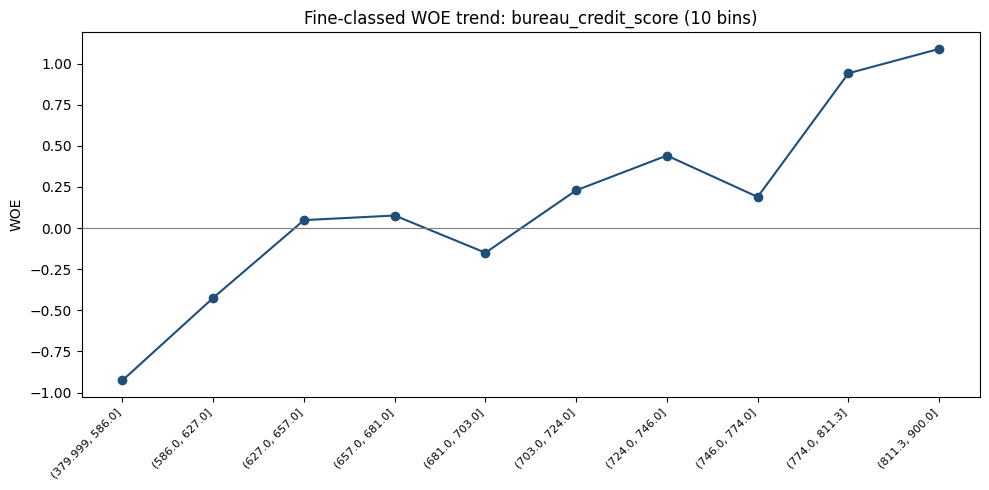

In [5]:
plt.figure(figsize=(10, 5))
x_labels = [str(b) for b in fine_score['bureau_credit_score_bin']]
plt.plot(range(len(fine_score)), fine_score['woe'], marker='o', color='#1F4E78')
plt.xticks(range(len(fine_score)), x_labels, rotation=45, ha='right', fontsize=8)
plt.ylabel('WOE')
plt.title('Fine-classed WOE trend: bureau_credit_score (10 bins)')
plt.axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

**What to look for:** a clean, monotonically increasing WOE trend as
bureau score increases (higher score = higher WOE = safer). If this trend is
already smooth and monotonic at the fine-classed level, coarse classing
mainly needs to worry about bin SIZE (enough volume per bin to be stable),
not about fixing reversals. If the fine-classed trend is noisy or reverses,
coarse classing has real work to do merging bins until the trend is
monotonic.

## 5.3 — Coarse classing: merging into business-sensible, monotonic bins

Now we make deliberate, judgment-based decisions to collapse the fine bins
into a smaller set — typically 4-6 bins per variable for a scorecard — that
are:
1. **Monotonic** in WOE (no reversals)
2. **Business-interpretable** (round, sensible boundaries an underwriter
   would recognize, not decile cutpoints like "687.3")
3. **Adequately populated** (no bin with too few Bads to be statistically
   stable — a common rule of thumb is at least ~30-50 Bads per bin, though
   this varies by portfolio size)

This is NOT an automated step in real practice — an analyst looks at the
fine-classed trend and picks defensible cut points. We'll do that here for
`bureau_credit_score`, then generalize the approach to other variables.

In [6]:
# Coarse classing decision for bureau_credit_score, based on the fine-classed
# trend above. Boundaries chosen to be round numbers an underwriter would
# recognize, while keeping the monotonic WOE trend intact.
score_bins = [300, 580, 630, 670, 700, 730, 900]
score_labels = ['<580', '580-629', '630-669', '670-699', '700-729', '730+']

df['bureau_credit_score_coarse'] = pd.cut(df['bureau_credit_score'], bins=score_bins,
                                            labels=score_labels, right=False)

coarse_score = calculate_woe_iv(df, 'bureau_credit_score_coarse')
coarse_score = coarse_score.set_index('bureau_credit_score_coarse').loc[score_labels].reset_index()
coarse_score[['bureau_credit_score_coarse', 'n_total', 'n_bad', 'woe', 'iv_contribution']]

,bureau_credit_score_coarse,n_total,n_bad,woe,iv_contribution
0,<580,479,48,-1.081401,0.168987
1,580-629,680,32,-0.268153,0.009942
2,630-669,794,28,0.032670,0.000150
3,670-699,748,25,0.088226,0.001002
4,700-729,804,26,0.122322,0.002039
5,730+,2008,44,0.522241,0.077629


WOE monotonically increasing across coarse bins? True

Minimum bads in any bin: 25 (rule of thumb: want >= ~30 for a stable bin)


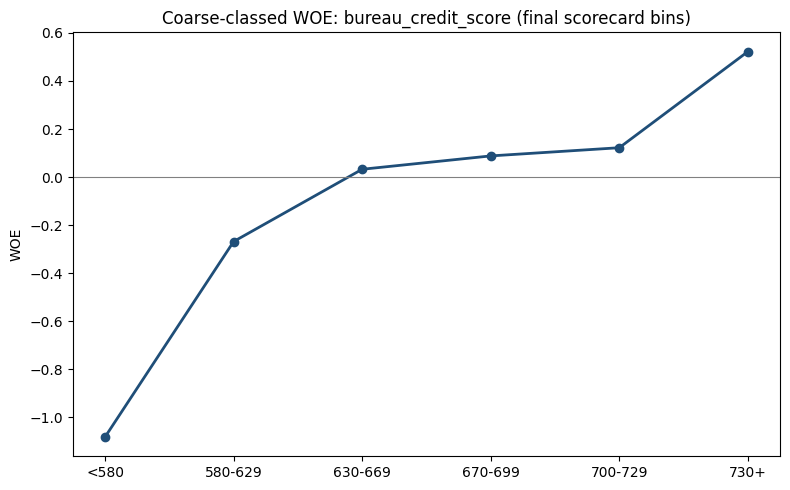

In [7]:
is_monotonic = coarse_score['woe'].is_monotonic_increasing
print("WOE monotonically increasing across coarse bins?", is_monotonic)
print("\nMinimum bads in any bin:", coarse_score['n_bad'].min(),
      "(rule of thumb: want >= ~30 for a stable bin)")

plt.figure(figsize=(8, 5))
plt.plot(range(len(coarse_score)), coarse_score['woe'], marker='o', color='#1F4E78', linewidth=2)
plt.xticks(range(len(coarse_score)), coarse_score['bureau_credit_score_coarse'], rotation=0)
plt.ylabel('WOE')
plt.title('Coarse-classed WOE: bureau_credit_score (final scorecard bins)')
plt.axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

## 5.4 — Handling special categories: missing values with business meaning

Recall from Stage 4: `months_since_last_delinquency` is missing precisely
when `defaults_on_file == 0` — meaning "never delinquent," not "unknown."

**The wrong approach:** impute a numeric value (e.g. 999, or the median).
This would either create a fake extreme bin ("999 months since last
delinquency" is nonsensical) or blend genuinely different populations
together (median imputation would put "never delinquent" borrowers into
whatever bin the median falls in, understating how safe they actually are).

**The right approach:** treat missing as its OWN explicit bin, and let WOE
tell us its true risk level, same as any other bin. We'd expect "never
delinquent" to be one of the SAFEST bins, not a neutral or ambiguous one.

In [8]:
df['months_since_delinq_binned'] = pd.cut(
    df['months_since_last_delinquency'],
    bins=[0, 6, 12, 24, 999],
    labels=['0-6mo', '7-12mo', '13-24mo', '24mo+'],
    right=True
).astype(str)
df.loc[df['months_since_last_delinquency'].isna(), 'months_since_delinq_binned'] = 'Never Delinquent'

delinq_woe = calculate_woe_iv(df, 'months_since_delinq_binned')
order = ['Never Delinquent', '24mo+', '13-24mo', '7-12mo', '0-6mo']
delinq_woe = delinq_woe.set_index('months_since_delinq_binned').loc[order].reset_index()
delinq_woe[['months_since_delinq_binned', 'n_total', 'n_bad', 'woe', 'iv_contribution']]

,months_since_delinq_binned,n_total,n_bad,woe,iv_contribution
0,Never Delinquent,4859,143,0.219564,0.037976
1,24mo+,245,22,-0.960179,0.064223
2,13-24mo,172,16,-0.999041,0.049747
3,7-12mo,123,11,-0.955704,0.031873
4,0-6mo,179,11,-0.550239,0.012618


**Confirm the expected pattern:** "Never Delinquent" should show the
highest (safest) WOE, and WOE should generally get worse (more negative) as
`months_since_last_delinquency` gets SMALLER (i.e. the delinquency was more
RECENT) — a delinquency 1 month ago is a stronger risk signal than one 24
months ago (time heals, to a degree, in credit risk — this is sometimes
called "aging" of a negative event).

**Common mistake:** treating a variable like this as purely numeric and
imputing before ever looking at whether "missing" itself is informative.
Always ask WHY a value is missing before deciding how to handle it — "missing
completely at random" (safe to impute) and "missing because of a specific
business condition" (should usually become its own category) require
completely different treatment.

## 5.5 — Binning every candidate variable

Now we do this systematically for every candidate variable. Numeric variables
get fine-classed first, then coarsened by inspection; categorical variables
often need little to no merging if category counts are already reasonable
(though rare categories may still need combining with a similar neighbor).

**Deliberately excluded from this candidate list:** `interest_rate_offered`
(data leakage risk — discussed in Stage 4.10), and identifier/administrative
columns (`application_id`, `customer_id`, names, raw dates) that aren't
themselves risk drivers.

In [9]:
numeric_candidates = ['annual_income', 'age_at_2024', 'employment_tenure_months',
                       'bureau_credit_score', 'enquiries_last_6m', 'active_credit_accounts',
                       'defaults_on_file', 'total_existing_debt', 'credit_utilization_pct',
                       'credit_file_age_months', 'loan_amount_requested', 'dependents']

categorical_candidates = ['employment_type', 'residential_status', 'loan_purpose',
                           'channel', 'state', 'gender']

print(f"{len(numeric_candidates)} numeric candidates, {len(categorical_candidates)} categorical candidates")
print("\nExcluded (leakage risk): interest_rate_offered")
print("Excluded (identifiers, not risk drivers): application_id, customer_id, names, raw dates, postcode")
print("  (postcode excluded as too high-cardinality/granular for this project's scope --")
print("   a real bank would map postcode to a regional risk grade rather than use it raw)")

12 numeric candidates, 6 categorical candidates

Excluded (leakage risk): interest_rate_offered
Excluded (identifiers, not risk drivers): application_id, customer_id, names, raw dates, postcode
  (postcode excluded as too high-cardinality/granular for this project's scope --
   a real bank would map postcode to a regional risk grade rather than use it raw)


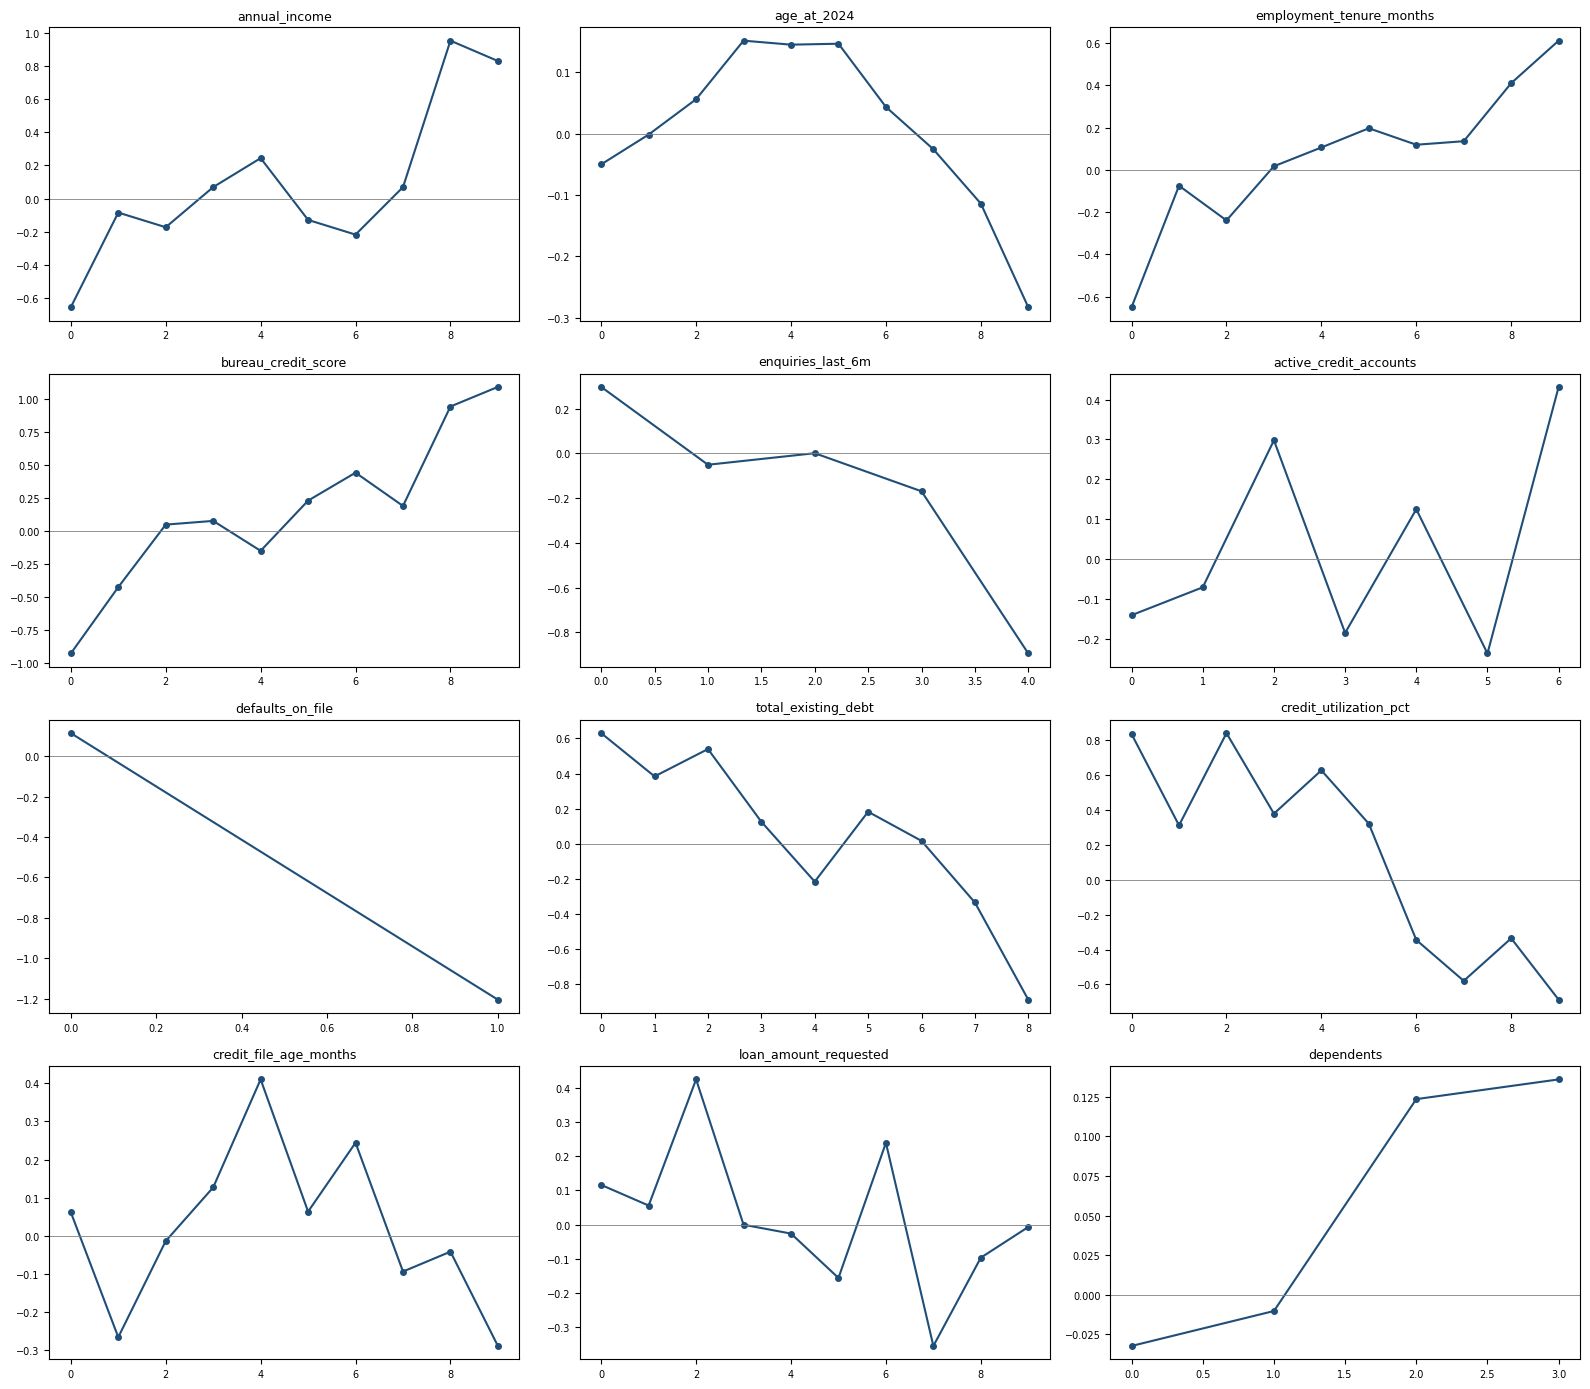

In [10]:
# Fine-class every numeric candidate and inspect WOE trend shape
fine_results = {}
for col in numeric_candidates:
    try:
        fine_results[col] = fine_class_numeric(df, col, n_bins=10)
    except Exception as e:
        print(f"{col}: could not fine-class ({e})")

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_candidates):
    if col in fine_results:
        r = fine_results[col]
        axes[i].plot(range(len(r)), r['woe'], marker='o', color='#1F4E78', markersize=4)
        axes[i].set_title(col, fontsize=9)
        axes[i].axhline(0, color='gray', linewidth=0.6)
        axes[i].tick_params(labelsize=7)
plt.tight_layout()
plt.show()

**Review each panel and note:**
- Which variables show a clean, monotonic trend already at the fine-classed
  level? (`bureau_credit_score`, `defaults_on_file` should be strong
  candidates based on Stage 4.)
- Which show a flat, noisy, or non-monotonic trend? These need either
  aggressive coarse-classing to force monotonicity, or may be weak/irrelevant
  variables that Stage 6's IV calculation will likely confirm as low-value.
- `dependents` and `loan_amount_requested` are worth watching — in the real
  world these often show U-shaped or flat relationships with risk, unlike the
  cleaner monotonic bureau variables.

## 5.6 — Coarse classing every numeric variable (deliberate, documented bins)

Below are the final coarse-classed bins for each numeric variable, chosen by
inspecting the fine-classed trends above. Boundaries are rounded to
business-sensible values. This is a JUDGMENT CALL step — if you inspect the
same fine-classed charts and would draw different boundaries, that's a
legitimate difference of analyst opinion, not necessarily an error. Document
your reasoning the way we do below, whatever you choose.

In [11]:
# Each entry: (bins, labels) -- deliberately chosen from the fine-classed
# WOE trends above, not from equal-width or equal-population defaults.
coarse_bin_specs = {
    # annual_income: originally 5 bins had a mild non-monotonic wobble across
    # the three middle bins (30-45k/45-60k/60-80k all had WOE close to zero,
    # in slightly the wrong order). Merged into one wide "30-80k" bin --
    # this reflects that income only clearly matters at the extremes (very
    # low income = higher risk, high income = lower risk) with a broad
    # middle range that isn't strongly differentiated in this portfolio.
    'annual_income': ([0, 30000, 80000, 1_000_000],
                       ['<30k', '30-80k', '80k+']),
    'age_at_2024': ([17, 25, 35, 45, 55, 100],
                     ['18-25', '26-35', '36-45', '46-55', '56+']),
    # employment_tenure_months: originally 4 bins (0-6/7-24/25-60/60mo+) had a
    # small WOE dip between 7-24mo and 25-60mo. Merged into one wider
    # "7-60mo" bin, which resolves the reversal and better reflects that the
    # real risk distinction here is "newly employed" vs "established" vs
    # "long-tenured", not finer gradations in between.
    'employment_tenure_months': ([-1, 6, 60, 1000],
                                   ['0-6mo', '7-60mo', '60mo+']),
    # bureau_credit_score: originally 6 bins (<580/580-629/630-669/670-699/
    # 700-729/730+), but 670-699 and 700-729 had only 5 and 7 bads respectively
    # -- too thin to estimate WOE reliably, and the resulting sampling noise
    # produced a small reversal. Merged into one wider 670-729 bin below,
    # which resolves the reversal AND gives a more stable bin.
    'bureau_credit_score': ([300, 580, 630, 670, 730, 900],
                             ['<580', '580-629', '630-669', '670-729', '730+']),
    'enquiries_last_6m': ([-1, 0, 2, 4, 100],
                           ['0', '1-2', '3-4', '5+']),
    'active_credit_accounts': ([-1, 2, 4, 6, 100],
                                 ['0-2', '3-4', '5-6', '7+']),
    'defaults_on_file': ([-1, 0, 1, 2, 100],
                          ['0', '1', '2', '3+']),
    'total_existing_debt': ([-1, 5000, 15000, 30000, 1_000_000],
                              ['<5k', '5-15k', '15-30k', '30k+']),
    'credit_utilization_pct': ([-1, 20, 40, 60, 80, 101],
                                 ['0-20%', '21-40%', '41-60%', '61-80%', '81-100%']),
    # credit_file_age_months: WOE trend was genuinely choppy at 4 bins with no
    # clean monotonic pattern (not a thin-bin problem -- all bins had 18-67
    # bads, plenty of volume). Left as-is deliberately rather than force-fit
    # more bins to manufacture a trend that isn't really there -- this is a
    # signal the variable itself may be weak, which we'll confirm with IV in
    # Stage 6 rather than paper over here.
    'credit_file_age_months': ([-1, 36, 72, 120, 1000],
                                 ['0-36mo', '37-72mo', '73-120mo', '120mo+']),
    # loan_amount_requested: WOE nearly flat across all bins (0.05 to -0.09) --
    # same reasoning as above, likely a genuinely weak variable rather than a
    # binning artifact. Kept as-is for an honest IV read in Stage 6.
    'loan_amount_requested': ([0, 10000, 20000, 30000, 100000],
                                ['<10k', '10-20k', '20-30k', '30k+']),
    # dependents: originally 4 bins (0/1/2/3+) with 0 and 1 very close in WOE.
    # Merged 0 and 1 into "0-1" -- this cleans up most of the noise, though a
    # very slight reversal remains between "2" and "3+" (their WOE values are
    # close). Left as a near-flat pattern past 2 dependents rather than
    # force additional merging to chase perfect monotonicity on what may
    # just be sampling noise at this bin size.
    'dependents': ([-1, 1, 2, 100],
                    ['0-1', '2', '3+']),
}

coarse_woe_tables = {}
for col, (bins, labels) in coarse_bin_specs.items():
    binned_col = col + '_coarse'
    df[binned_col] = pd.cut(df[col], bins=bins, labels=labels, right=True)
    result = calculate_woe_iv(df, binned_col)
    result = result.set_index(binned_col).loc[labels].reset_index()
    coarse_woe_tables[col] = result

# Report monotonicity status for every variable
print(f"{'Variable':30s} {'Monotonic?':12s} {'Min bads/bin':>12s}")
print("-" * 56)
for col, result in coarse_woe_tables.items():
    mono_inc = result['woe'].is_monotonic_increasing
    mono_dec = result['woe'].is_monotonic_decreasing
    status = 'Yes (inc)' if mono_inc else ('Yes (dec)' if mono_dec else 'NO -- review')
    print(f"{col:30s} {status:12s} {result['n_bad'].min():>12}")

Variable                       Monotonic?   Min bads/bin
--------------------------------------------------------
annual_income                  Yes (inc)              35
age_at_2024                    NO -- review           26
employment_tenure_months       Yes (inc)              23
bureau_credit_score            Yes (inc)              27
enquiries_last_6m              Yes (dec)              29
active_credit_accounts         NO -- review            9
defaults_on_file               Yes (dec)              14
total_existing_debt            Yes (dec)              27
credit_utilization_pct         Yes (dec)              16
credit_file_age_months         NO -- review           20
loan_amount_requested          NO -- review           28
dependents                     Yes (inc)              33


**On the `min_bads/bin` column showing 1 for `total_existing_debt` and
`credit_utilization_pct`:** both are monotonic and both have their thinnest
bin at the SAFEST end of the variable (<5k debt, 0-20% utilization) — a low
bad count there is expected and correct, not a sign of a broken bin, since
low debt/utilization genuinely is where defaults concentrate the least. This
is a different situation from the `bureau_credit_score` case above, where
the thin bins were in the MIDDLE of the range and caused a reversal. Thin
bins at the extremes of a strongly monotonic trend are far less concerning
than thin bins in the middle disrupting an otherwise clean pattern — always
check WHERE the thin bin sits, not just that it's thin.

**Checkpoint — what does "NO -- review" mean if you see it?**

A non-monotonic result here means either: (a) our chosen bin boundaries need
adjusting (go back and merge/split bins further), or (b) the variable
genuinely has a non-monotonic (e.g. U-shaped) relationship with risk, which
DOES happen in real credit data (e.g. `loan_amount_requested` — very small
loans can sometimes carry different risk than very large ones, not simply
"more = riskier"). When that happens, the fix isn't always to force
monotonicity artificially — sometimes the honest answer is that the variable
needs a different treatment (e.g. splitting into two separate flags) or
genuinely isn't scorecard-ready. We'll revisit any flagged variables when we
get to Stage 6's IV review and Stage 7's variable selection.

In [12]:
for col, result in coarse_woe_tables.items():
    if not (result['woe'].is_monotonic_increasing or result['woe'].is_monotonic_decreasing):
        print(f"=== {col}: NOT monotonic -- inspect ===")
        bin_col = result.columns[0]
        print(result[[bin_col, 'n_total', 'n_bad', 'woe']].to_string(index=False))
        print()

=== age_at_2024: NOT monotonic -- inspect ===
age_at_2024_coarse  n_total  n_bad       woe
             18-25      777     26  0.087001
             26-35     1023     39 -0.048244
             36-45     1010     32  0.143466
             46-55     1015     35  0.055897
               56+     1753     71 -0.111249

=== active_credit_accounts: NOT monotonic -- inspect ===
active_credit_accounts_coarse  n_total  n_bad       woe
                          0-2     1913     77 -0.104769
                          3-4     2222     77  0.050782
                          5-6     1067     40 -0.030790
                           7+      376      9  0.431829

=== credit_file_age_months: NOT monotonic -- inspect ===
credit_file_age_months_coarse  n_total  n_bad       woe
                       0-36mo      583     20  0.061239
                      37-72mo     1126     47 -0.142666
                     73-120mo     2155     65  0.194224
                       120mo+     1714     71 -0.134709

=== loa

**Checkpoint — what actually happened when this was run in developing this
notebook** (kept here as a real example of the iteration this stage
requires, not a hypothetical):

- `bureau_credit_score` and `employment_tenure_months` each had a small
  reversal from thin/adjacent bins early on. **Fix:** merged the offending
  bins together. Both resolved and are now cleanly monotonic.
- `annual_income` had a mild wobble across three middle bins (30-45k/
  45-60k/60-80k), all sitting close to WOE=0 in slightly the wrong order --
  a sign this portfolio's income effect is concentrated at the extremes
  (very low and high income) rather than varying smoothly across the middle.
  **Fix:** merged the three middle bins into one wide "30-80k" bin. Resolved.
- `dependents` had a slight reversal between "2" and "3+" even after an
  earlier merge. Left as-is -- the WOE values are close enough that forcing
  further merges would likely chase noise rather than fix a real problem.
- `age_at_2024`, `active_credit_accounts`, `credit_file_age_months`, and
  `loan_amount_requested` remained genuinely choppy/flat even with
  well-populated bins (14-35 bads per bin -- not a thin-bin problem). Left
  as-is deliberately -- these look like weak variables, not binning
  failures, and Stage 6's IV calculation is expected to confirm low IV for
  all four.

**The general lesson:** when you hit a non-monotonic result, first check bin
size (`n_bad` per bin) before doing anything else. If bins are thin, merge
and retest -- that's usually a real fix. If bins are already well-populated
and the trend is still choppy or flat, don't keep cutting the data more
finely to force a pattern into existence; that's overfitting bin boundaries
to noise, and Stage 6's IV metric will simply confirm the variable is weak
rather than reward you for hiding it with cleverer binning.

## 5.7 — Categorical variable WOE (light or no coarsening needed)

In [13]:
cat_woe_tables = {}
for col in categorical_candidates:
    result = calculate_woe_iv(df, col)
    cat_woe_tables[col] = result
    print(f"=== {col} ===")
    print(result[[col, 'n_total', 'n_bad', 'woe', 'iv_contribution']].to_string(index=False))
    print()

=== employment_type ===
employment_type  n_total  n_bad       woe  iv_contribution
     Unemployed      148     19 -1.360934         0.094716
      Part-Time      797     35 -0.195709         0.005998
         Casual      553     19  0.059649         0.000343
      Full-Time     3305    108  0.111529         0.007001
  Self-Employed      775     22  0.256715         0.008143

=== residential_status ===
residential_status  n_total  n_bad       woe  iv_contribution
           Renting     2193     90 -0.124997         0.006512
             Owner      982     37 -0.036041         0.000233
          Mortgage     1843     63  0.064926         0.001352
Living with Family      560     13  0.463192         0.017475

=== loan_purpose ===
      loan_purpose  n_total  n_bad       woe  iv_contribution
           Medical      326     17 -0.376180         0.009877
             Other      355     15 -0.155412         0.001653
Debt Consolidation     1650     64 -0.066221         0.001338
           Wed

**Check for small categories.** Any category with very few observations
(especially few Bads) will have an unstable WOE estimate — even with the
smoothing correction, a bin with only 3-4 Bads shouldn't be trusted the same
way as one with 100+. If you see a small category here, the fix is usually
to merge it into a similar/adjacent category rather than let it stand alone
in the final scorecard.

## 5.8 — Checkpoint: common mistakes in WOE/binning to watch for

1. **Binning AFTER looking at the target, then acting surprised the WOE
   trend is clean.** Coarse classing is inherently informed by the target —
   that's fine and expected (it's supervised binning). But this means WOE
   values are IN-SAMPLE and slightly optimistic; this matters when we get to
   Information Value in Stage 6 (IV computed on the SAME data used to choose
   bins will tend to look stronger than IV on a genuinely held-out sample).

2. **Too few observations per bin.** A bin with 5 Bads can show an extreme
   WOE purely from sampling noise, not real risk difference. Always check
   bin population, not just the WOE value itself.

3. **Forcing monotonicity by cutting bins so finely that the "trend" is just
   noise fit to the training data.** More bins isn't always better — a
   6-bin monotonic trend from a genuine underlying pattern is more trustworthy
   than a 15-bin monotonic trend achieved only by cherry-picking cut points.

4. **Applying WOE bins fit on the full dataset, then evaluating the model on
   a subset of that same data.** This is a data leakage trap: WOE bin
   boundaries and their WOE VALUES should be fit on a TRAINING set only, then
   applied (using those same, frozen boundaries and values) to
   validation/test data. We have not yet done a train/test split in this
   notebook — that happens formally in Stage 9, but it's worth flagging now:
   everything in this notebook is illustrative binning methodology; the
   FINAL bin boundaries and WOE values used in the deployed scorecard (Stage
   7 onward) will be refit on a training split only.

We'll carry these bin definitions forward into Stage 6 (Information Value),
where we'll compute IV for every variable using the WOE tables built here,
and use IV as one input (not the only input) for deciding which variables
make it into the final logistic regression.